# MedSum-AI: Feature Engineering
## Notebook 03 — Engineering 25 Structured Features for Outcome Prediction (RQ4)

**Feature Categories (from Interim Report):**
1. NLP-derived features (from report text)
2. Report structural features
3. Pathology category features
4. Linguistic complexity features
5. Clinical severity features
6. Derived composite features


In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded!")


Libraries loaded!


## Load Cleaned Data

In [2]:
df = pd.read_csv('../data/iu_cxr_cleaned.csv')
print(f"Loaded cleaned dataset: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Use cleaned text for feature engineering
df['text'] = df['findings_clean'].fillna('') + ' ' + df['impression_clean'].fillna('')
df['text'] = df['text'].str.strip()
print(f"\nRecords with non-empty text: {(df['text'] != '').sum()}")


Loaded cleaned dataset: (2985, 36)
Columns: ['uid', 'pmc_id', 'filename', 'findings', 'impression', 'indication', 'comparison', 'findings_clean', 'impression_clean', 'indication_clean', 'mesh_major', 'mesh_minor', 'num_images', 'image_ids', 'dataset_source', 'findings_word_count', 'impression_word_count', 'indication_word_count', 'total_word_count', 'findings_char_count', 'impression_char_count', 'findings_sentence_count', 'impression_sentence_count', 'is_normal', 'pathology_categories', 'has_Normal', 'has_Cardiomegaly', 'has_Opacity/Mass', 'has_Atelectasis', 'has_Pleural Effusion', 'has_Pneumonia', 'has_Emphysema/COPD', 'has_Edema', 'has_xxxx', 'avg_sentence_len', 'num_pathologies']

Records with non-empty text: 2985


## Category 1: NLP-Derived Features

In [3]:
# Feature 1: Sentiment/Polarity Score (positive findings vs negative/normal)
# In clinical context: presence of positive findings = higher score
positive_terms = ['normal', 'unremarkable', 'clear', 'stable', 'no change', 'within normal',
                  'no evidence', 'no acute', 'no significant', 'resolved', 'improved']
negative_terms = ['abnormal', 'consolidation', 'opacity', 'effusion', 'mass', 'nodule',
                  'cardiomegaly', 'edema', 'pneumothorax', 'fracture', 'worsening',
                  'enlarged', 'increased', 'infiltrate', 'collapse']

def clinical_sentiment(text):
    text_lower = str(text).lower()
    pos_count = sum(1 for t in positive_terms if t in text_lower)
    neg_count = sum(1 for t in negative_terms if t in text_lower)
    total = pos_count + neg_count
    if total == 0:
        return 0.5
    return neg_count / total  # Higher = more pathological findings

df['F01_clinical_sentiment'] = df['text'].apply(clinical_sentiment)

# Feature 2: Clinical Entity Count
clinical_entities = ['lung', 'heart', 'cardiac', 'mediastin', 'pleural', 'aort',
                     'spine', 'rib', 'diaphragm', 'hilum', 'bronch', 'trachea',
                     'pulmonary', 'thoracic', 'sternum', 'clavicle', 'pericard']

def count_entities(text):
    text_lower = str(text).lower()
    return sum(1 for e in clinical_entities if e in text_lower)

df['F02_clinical_entity_count'] = df['text'].apply(count_entities)

# Feature 3: Finding Severity Score
severity_keywords = {
    'mild': 1, 'minimal': 1, 'slight': 1, 'small': 1, 'trace': 1,
    'moderate': 2, 'partial': 2, 
    'severe': 3, 'significant': 3, 'large': 3, 'marked': 3, 'extensive': 3,
    'massive': 4, 'critical': 4, 'complete': 4
}

def severity_score(text):
    text_lower = str(text).lower()
    scores = [v for k, v in severity_keywords.items() if k in text_lower]
    return max(scores) if scores else 0

df['F03_severity_score'] = df['text'].apply(severity_score)

# Feature 4: Diagnostic Term Frequency
diagnostic_terms = ['diagnosis', 'consistent with', 'suggestive of', 'compatible with',
                    'likely', 'probable', 'suspect', 'concerning for', 'indicative of',
                    'represent', 'confirmed', 'evidence of']

def diagnostic_freq(text):
    text_lower = str(text).lower()
    return sum(1 for t in diagnostic_terms if t in text_lower)

df['F04_diagnostic_term_freq'] = df['text'].apply(diagnostic_freq)

# Feature 5: Impression Length (words)
df['F05_impression_length'] = df['impression_clean'].fillna('').apply(lambda x: len(x.split()))

print("NLP-derived features (F01-F05) computed!")
print(df[['F01_clinical_sentiment', 'F02_clinical_entity_count', 'F03_severity_score',
           'F04_diagnostic_term_freq', 'F05_impression_length']].describe().round(3))


NLP-derived features (F01-F05) computed!
       F01_clinical_sentiment  F02_clinical_entity_count  F03_severity_score  \
count                2985.000                   2985.000            2985.000   
mean                    0.503                      4.100               0.995   
std                     0.224                      1.453               1.256   
min                     0.000                      0.000               0.000   
25%                     0.400                      3.000               0.000   
50%                     0.500                      4.000               0.000   
75%                     0.625                      5.000               2.000   
max                     1.000                     10.000               4.000   

       F04_diagnostic_term_freq  F05_impression_length  
count                  2985.000               2985.000  
mean                      0.324                 12.335  
std                       0.539                 13.154  
min       

## Category 2: Report Structural Features

In [4]:
# Feature 6: Word Count (total)
df['F06_word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Feature 7: Sentence Count
df['F07_sentence_count'] = df['text'].apply(lambda x: len([s for s in str(x).split('.') if s.strip()]))

# Feature 8: Findings-to-Impressions Ratio
findings_wc = df['findings_clean'].fillna('').apply(lambda x: len(x.split()))
impression_wc = df['impression_clean'].fillna('').apply(lambda x: len(x.split()))
df['F08_findings_impression_ratio'] = findings_wc / impression_wc.replace(0, 1)

# Feature 9: Presence of Measurement Terms
measurement_patterns = [r'\d+\s*(mm|cm|ml|cc)', r'\d+\.\d+', r'\d+\s*x\s*\d+']
def has_measurements(text):
    text = str(text)
    return int(any(re.search(p, text, re.IGNORECASE) for p in measurement_patterns))

df['F09_has_measurements'] = df['text'].apply(has_measurements)

# Feature 10: Negation Count
negation_patterns = ['no ', 'not ', 'without ', 'absent', 'unremarkable', 'negative',
                     'denies', 'no evidence', 'none', 'neither']

def count_negations(text):
    text_lower = str(text).lower()
    return sum(text_lower.count(n) for n in negation_patterns)

df['F10_negation_count'] = df['text'].apply(count_negations)

print("Report structural features (F06-F10) computed!")
print(df[['F06_word_count', 'F07_sentence_count', 'F08_findings_impression_ratio',
           'F09_has_measurements', 'F10_negation_count']].describe().round(3))


Report structural features (F06-F10) computed!
       F06_word_count  F07_sentence_count  F08_findings_impression_ratio  \
count        2985.000            2985.000                       2985.000   
mean           42.207               5.811                          4.802   
std            21.324               2.688                          3.899   
min             3.000               1.000                          0.000   
25%            28.000               4.000                          2.125   
50%            38.000               5.000                          4.222   
75%            52.000               7.000                          7.000   
max           230.000              31.000                         47.000   

       F09_has_measurements  F10_negation_count  
count              2985.000            2985.000  
mean                  0.044               2.519  
std                   0.204               1.411  
min                   0.000               0.000  
25%               

## Category 3: Pathology Category Features

In [5]:
# Feature 11: Primary Pathology Category (encoded)
pathology_map = {
    'Normal': ['normal'],
    'Cardiomegaly': ['cardiomegaly'],
    'Opacity/Mass': ['opacity', 'mass', 'nodule', 'lesion'],
    'Atelectasis': ['atelectasis'],
    'Pleural Effusion': ['pleural effusion', 'effusion'],
    'Pneumonia': ['pneumonia', 'consolidation', 'infiltrate', 'airspace disease'],
    'Emphysema/COPD': ['emphysema', 'copd', 'chronic obstructive', 'hyperdistention'],
    'Edema': ['edema', 'congestion'],
    'Fracture': ['fracture'],
    'Pneumothorax': ['pneumothorax']
}

def get_primary_pathology(mesh):
    mesh_lower = str(mesh).lower()
    for cat, keywords in pathology_map.items():
        if any(kw in mesh_lower for kw in keywords):
            return cat
    return 'Other'

df['F11_primary_pathology'] = df['mesh_major'].apply(get_primary_pathology)

# Feature 12: Multi-label Co-occurrence Flag
def count_pathologies(mesh):
    mesh_lower = str(mesh).lower()
    count = 0
    for cat, keywords in pathology_map.items():
        if any(kw in mesh_lower for kw in keywords):
            count += 1
    return count

df['F12_multi_label_count'] = df['mesh_major'].apply(count_pathologies)
df['F12_is_multilabel'] = (df['F12_multi_label_count'] > 1).astype(int)

print("Pathology category features (F11-F12) computed!")
print(f"\nPrimary pathology distribution:")
print(df['F11_primary_pathology'].value_counts())
print(f"\nMulti-label reports: {df['F12_is_multilabel'].sum()} ({100*df['F12_is_multilabel'].mean():.1f}%)")


Pathology category features (F11-F12) computed!

Primary pathology distribution:
F11_primary_pathology
Other               1119
Normal               549
Opacity/Mass         466
Cardiomegaly         372
Emphysema/COPD       194
Atelectasis          128
Pleural Effusion      52
Fracture              50
Pneumonia             43
Edema                  6
Pneumothorax           6
Name: count, dtype: int64

Multi-label reports: 544 (18.2%)


## Category 4: Linguistic Complexity Features

In [6]:
# Feature 13: Flesch-Kincaid Readability (simplified)
def flesch_kincaid(text):
    words = str(text).split()
    sentences = [s for s in str(text).split('.') if s.strip()]
    if len(words) < 1 or len(sentences) < 1:
        return 0
    syllables = sum(max(1, len(re.findall(r'[aeiouy]+', w, re.IGNORECASE))) for w in words)
    asl = len(words) / len(sentences)
    asw = syllables / len(words)
    return 0.39 * asl + 11.8 * asw - 15.59

df['F13_flesch_kincaid'] = df['text'].apply(flesch_kincaid)

# Feature 14: Medical Abbreviation Density
common_abbrevs = ['AP', 'PA', 'CT', 'CXR', 'ICU', 'COPD', 'CHF', 'ETT', 'NG',
                  'RLL', 'LLL', 'RUL', 'LUL', 'RML', 'CABG', 'DJD', 'ICD', 'IV']
def abbrev_density(text):
    words = str(text).split()
    if len(words) == 0:
        return 0
    abbrev_count = sum(1 for w in words if w.upper() in common_abbrevs)
    return abbrev_count / len(words)

df['F14_abbrev_density'] = df['text'].apply(abbrev_density)

# Feature 15: Numerical Value Count
def count_numbers(text):
    return len(re.findall(r'\b\d+\.?\d*\b', str(text)))

df['F15_numerical_count'] = df['text'].apply(count_numbers)

# Feature 16: Uncertainty Hedge Count
hedges = ['possibly', 'probably', 'may', 'might', 'could', 'suggest', 'appear',
           'likely', 'cannot exclude', 'cannot rule out', 'questionable', 'uncertain']
def count_hedges(text):
    text_lower = str(text).lower()
    return sum(1 for h in hedges if h in text_lower)

df['F16_hedge_count'] = df['text'].apply(count_hedges)

# Feature 17: Passive Voice Ratio
def passive_ratio(text):
    words = str(text).lower().split()
    if len(words) < 3:
        return 0
    passive_indicators = ['is ', 'are ', 'was ', 'were ', 'been ', 'being ']
    passive_count = sum(str(text).lower().count(p) for p in passive_indicators)
    return passive_count / len(words)

df['F17_passive_ratio'] = df['text'].apply(passive_ratio)

# Feature 18: Temporal Marker Count
temporal_terms = ['prior', 'previous', 'interval', 'since', 'new', 'old', 'chronic',
                  'acute', 'progressive', 'stable', 'unchanged', 'worsening', 'improving']
def count_temporal(text):
    text_lower = str(text).lower()
    return sum(1 for t in temporal_terms if t in text_lower)

df['F18_temporal_count'] = df['text'].apply(count_temporal)

# Feature 19: Recommendation Presence Flag
recommendations = ['recommend', 'suggest', 'follow-up', 'followup', 'correlation',
                   'clinical correlation', 'further evaluation', 'CT scan', 'additional']
def has_recommendation(text):
    text_lower = str(text).lower()
    return int(any(r in text_lower for r in recommendations))

df['F19_has_recommendation'] = df['text'].apply(has_recommendation)

print("Linguistic complexity features (F13-F19) computed!")
print(df[['F13_flesch_kincaid', 'F14_abbrev_density', 'F15_numerical_count',
           'F16_hedge_count', 'F17_passive_ratio', 'F18_temporal_count',
           'F19_has_recommendation']].describe().round(3))


Linguistic complexity features (F13-F19) computed!
       F13_flesch_kincaid  F14_abbrev_density  F15_numerical_count  \
count            2985.000            2985.000             2985.000   
mean               14.043               0.001                0.504   
std                 3.192               0.006                0.956   
min                 2.230               0.000                0.000   
25%                11.896               0.000                0.000   
50%                14.093               0.000                0.000   
75%                16.152               0.000                1.000   
max                25.706               0.057               12.000   

       F16_hedge_count  F17_passive_ratio  F18_temporal_count  \
count         2985.000           2985.000            2985.000   
mean             0.387              0.066               1.142   
std              0.621              0.046               0.955   
min              0.000              0.000               0.

## Category 5: Clinical Severity Features

In [7]:
# Feature 20: Simplified Elixhauser Comorbidity Score
# Based on clinical terms that indicate comorbidities present in the text
comorbidity_terms = {
    'heart failure': 2, 'congestive': 2, 'CHF': 2,
    'hypertension': 1, 'diabetes': 2, 'renal': 2,
    'liver': 2, 'obesity': 1, 'cancer': 3, 'malignant': 3,
    'COPD': 2, 'emphysema': 2, 'asthma': 1,
    'arthritis': 1, 'anemia': 1, 'coagulopathy': 2,
    'depression': 1, 'hypothyroid': 1
}

def elixhauser_score(text):
    text_lower = str(text).lower()
    return sum(v for k, v in comorbidity_terms.items() if k.lower() in text_lower)

df['F20_elixhauser_score'] = df['text'].apply(elixhauser_score)

# Feature 21: Charlson Comorbidity Index (simplified from text)
charlson_terms = {
    'myocardial infarction': 1, 'heart failure': 1, 'peripheral vascular': 1,
    'cerebrovascular': 1, 'dementia': 1, 'pulmonary disease': 1, 'COPD': 1,
    'connective tissue': 1, 'peptic ulcer': 1, 'liver disease': 1,
    'diabetes': 1, 'hemiplegia': 2, 'renal disease': 2, 'malignant': 2,
    'metastatic': 6, 'AIDS': 6, 'leukemia': 2, 'lymphoma': 2
}

def charlson_score(text):
    text_lower = str(text).lower()
    return sum(v for k, v in charlson_terms.items() if k.lower() in text_lower)

df['F21_charlson_score'] = df['text'].apply(charlson_score)

print("Clinical severity features (F20-F21) computed!")
print(df[['F20_elixhauser_score', 'F21_charlson_score']].describe().round(3))
print(f"\nRecords with any comorbidity signal: {(df['F20_elixhauser_score'] > 0).sum()}")


Clinical severity features (F20-F21) computed!
       F20_elixhauser_score  F21_charlson_score
count              2985.000            2985.000
mean                  0.158               0.164
std                   0.564               0.599
min                   0.000               0.000
25%                   0.000               0.000
50%                   0.000               0.000
75%                   0.000               0.000
max                   4.000               7.000

Records with any comorbidity signal: 233


## Category 6: Derived Composite Features

In [8]:
# Feature 22: Composite Severity Index (weighted combination)
df['F22_composite_severity'] = (
    0.3 * df['F03_severity_score'] / df['F03_severity_score'].max() +
    0.25 * df['F01_clinical_sentiment'] +
    0.2 * df['F02_clinical_entity_count'] / df['F02_clinical_entity_count'].max() +
    0.15 * df['F20_elixhauser_score'] / max(df['F20_elixhauser_score'].max(), 1) +
    0.1 * df['F16_hedge_count'] / max(df['F16_hedge_count'].max(), 1)
)

# Feature 23: Pathology Confidence Score
# Higher when: more specific language, fewer hedges, more entities mentioned
df['F23_pathology_confidence'] = (
    df['F04_diagnostic_term_freq'] * 0.4 +
    (1 - df['F16_hedge_count'] / max(df['F16_hedge_count'].max(), 1)) * 0.3 +
    df['F02_clinical_entity_count'] / max(df['F02_clinical_entity_count'].max(), 1) * 0.3
)

# Feature 24: Report Complexity Score
df['F24_report_complexity'] = (
    df['F06_word_count'] / df['F06_word_count'].max() * 0.25 +
    df['F13_flesch_kincaid'] / max(abs(df['F13_flesch_kincaid']).max(), 1) * 0.25 +
    df['F15_numerical_count'] / max(df['F15_numerical_count'].max(), 1) * 0.25 +
    df['F07_sentence_count'] / max(df['F07_sentence_count'].max(), 1) * 0.25
)

# Feature 25: Abnormality Binary Flag (target variable for classification)
df['F25_is_abnormal'] = (df['F11_primary_pathology'] != 'Normal').astype(int)

print("Derived composite features (F22-F25) computed!")
print(df[['F22_composite_severity', 'F23_pathology_confidence', 
           'F24_report_complexity', 'F25_is_abnormal']].describe().round(3))
print(f"\nTarget variable distribution:")
print(df['F25_is_abnormal'].value_counts())
print(f"Abnormal rate: {100*df['F25_is_abnormal'].mean():.1f}%")


Derived composite features (F22-F25) computed!
       F22_composite_severity  F23_pathology_confidence  \
count                2985.000                  2985.000   
mean                    0.298                     0.524   
std                     0.137                     0.217   
min                     0.020                     0.150   
25%                     0.203                     0.390   
50%                     0.265                     0.420   
75%                     0.402                     0.715   
max                     0.738                     1.680   

       F24_report_complexity  F25_is_abnormal  
count               2985.000         2985.000  
mean                   0.240            0.816  
std                    0.062            0.387  
min                    0.055            0.000  
25%                    0.203            1.000  
50%                    0.235            1.000  
75%                    0.270            1.000  
max                    0.676         

## Feature Correlation Analysis

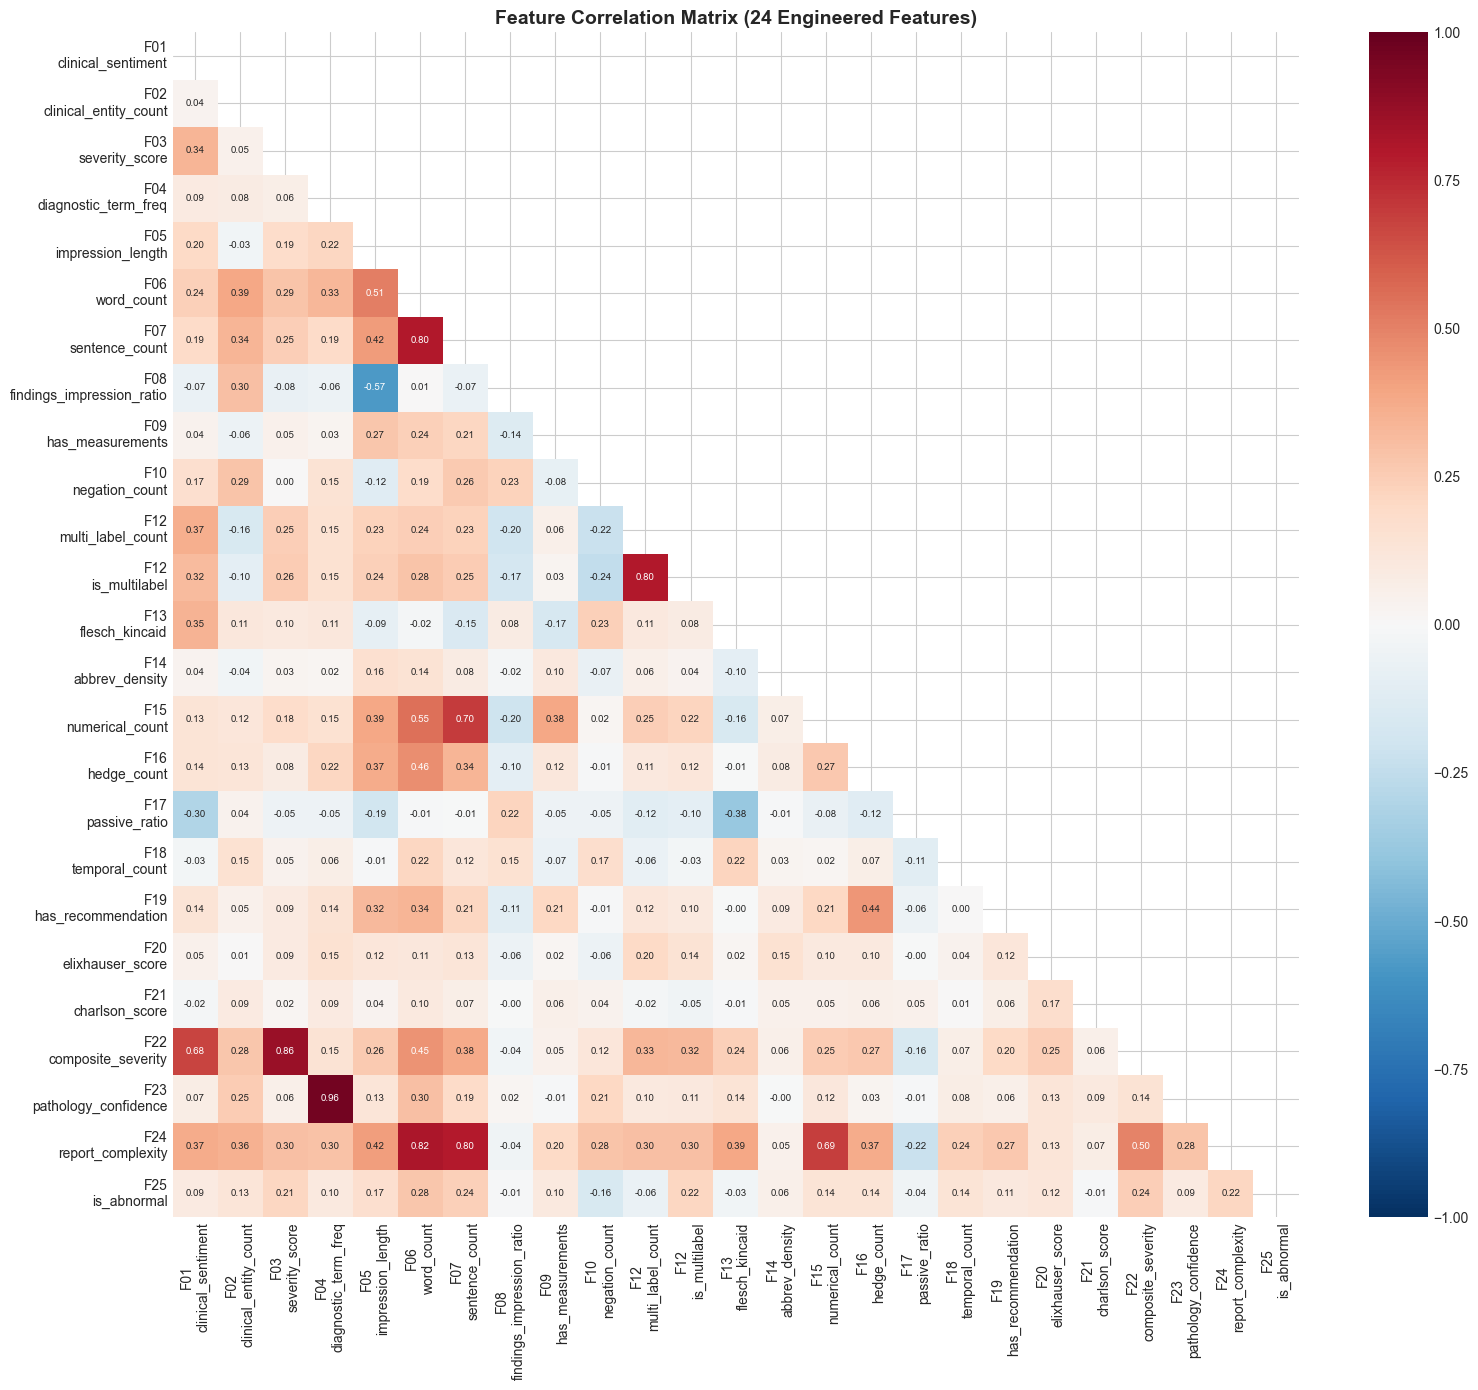


=== HIGH CORRELATIONS (|r| > 0.7) ===
  F03_severity_score ↔ F22_composite_severity: r = 0.863
  F04_diagnostic_term_freq ↔ F23_pathology_confidence: r = 0.962
  F06_word_count ↔ F07_sentence_count: r = 0.800
  F06_word_count ↔ F24_report_complexity: r = 0.820
  F07_sentence_count ↔ F15_numerical_count: r = 0.700
  F07_sentence_count ↔ F24_report_complexity: r = 0.796
  F12_multi_label_count ↔ F12_is_multilabel: r = 0.804


In [9]:
# Correlation heatmap of all 25 features
feature_cols = [c for c in df.columns if c.startswith('F') and c[1:3].isdigit()]
# Exclude categorical (F11)
numeric_features = [c for c in feature_cols if c != 'F11_primary_pathology']

fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = df[numeric_features].corr()

# Lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7},
            xticklabels=[c.replace('_', '\n', 1) for c in numeric_features],
            yticklabels=[c.replace('_', '\n', 1) for c in numeric_features])
ax.set_title('Feature Correlation Matrix (24 Engineered Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/08_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# VIF Analysis for multicollinearity
from numpy.linalg import inv
print("\n=== HIGH CORRELATIONS (|r| > 0.7) ===")
high_corr = []
for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((numeric_features[i], numeric_features[j], r))
            print(f"  {numeric_features[i]} ↔ {numeric_features[j]}: r = {r:.3f}")

if not high_corr:
    print("  None found — no multicollinearity concerns!")


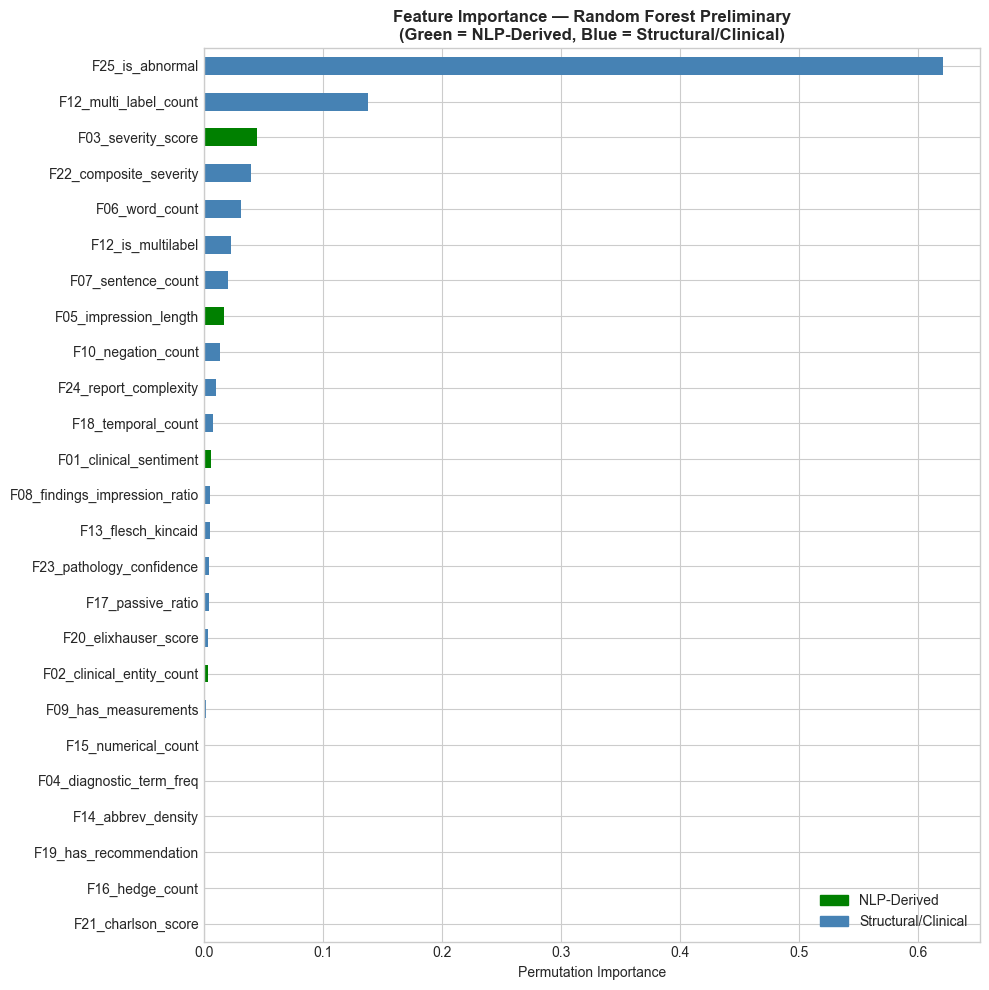


Top 10 Features by Importance:
F24_report_complexity     0.0100
F10_negation_count        0.0134
F05_impression_length     0.0166
F07_sentence_count        0.0199
F12_is_multilabel         0.0223
F06_word_count            0.0313
F22_composite_severity    0.0397
F03_severity_score        0.0445
F12_multi_label_count     0.1376
F25_is_abnormal           0.6209


In [10]:
# Feature importance preview (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare features for quick RF importance
X = df[numeric_features].fillna(0)
y = df['F25_is_abnormal']

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X, y)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=numeric_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['green' if 'F01' <= f[:3] <= 'F05' else 'steelblue' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Permutation Importance')
ax.set_title('Feature Importance — Random Forest Preliminary\n(Green = NLP-Derived, Blue = Structural/Clinical)', 
             fontweight='bold')
ax.legend(handles=[plt.Rectangle((0,0),1,1,color='green',label='NLP-Derived'),
                   plt.Rectangle((0,0),1,1,color='steelblue',label='Structural/Clinical')],
          loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 Features by Importance:")
print(importances.tail(10).round(4).to_string())


In [11]:
# Save feature-engineered dataset
df.to_csv('../data/iu_cxr_features.csv', index=False)
print(f"Feature-engineered dataset saved: ../data/iu_cxr_features.csv")
print(f"Shape: {df.shape}")
print(f"\nAll 25 features:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


Feature-engineered dataset saved: ../data/iu_cxr_features.csv
Shape: (2985, 63)

All 25 features:
   1. F01_clinical_sentiment
   2. F02_clinical_entity_count
   3. F03_severity_score
   4. F04_diagnostic_term_freq
   5. F05_impression_length
   6. F06_word_count
   7. F07_sentence_count
   8. F08_findings_impression_ratio
   9. F09_has_measurements
  10. F10_negation_count
  11. F11_primary_pathology
  12. F12_multi_label_count
  13. F12_is_multilabel
  14. F13_flesch_kincaid
  15. F14_abbrev_density
  16. F15_numerical_count
  17. F16_hedge_count
  18. F17_passive_ratio
  19. F18_temporal_count
  20. F19_has_recommendation
  21. F20_elixhauser_score
  22. F21_charlson_score
  23. F22_composite_severity
  24. F23_pathology_confidence
  25. F24_report_complexity
  26. F25_is_abnormal


## Secondary Dataset — CASIA-CXR Feature Engineering (French)

We engineer the **same 25 structured features** for the CASIA-CXR dataset,
adapted to French clinical vocabulary (lexicons translated, accents preserved).
The output is `data/casia_cxr_features.csv` — used for the secondary
5-class condition classifier in Notebook 05.

In [12]:
# Run the CASIA-CXR feature engineering via the shared pipeline module.
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from casia_cxr_pipeline import load_casia_reports, clean_casia, engineer_features as casia_features

df_ca_raw   = load_casia_reports(save=False)
df_ca_clean = clean_casia(df_ca_raw)
df_ca_feat  = casia_features(df_ca_clean)
print('\nCASIA-CXR feature dataframe:', df_ca_feat.shape)
df_ca_feat[[c for c in df_ca_feat.columns if c.startswith('F') and c[1:3].isdigit()]].describe().T


STEP 1: LOADING CASIA-CXR REPORTS
  Cardiomegaly       5,503 records, 19 cols
  Mass               2,030 records, 19 cols
  PleuralEffusion    2,000 records, 19 cols
  Pneumonia          2,139 records, 19 cols
  Pneumothorax       2,000 records, 19 cols

  Combined : 13,672 reports across 5 conditions

STEP 3: CASIA-CXR DATA CLEANSING
  After dropping null ExamID : 11,111
  After removing empty text  : 11,111
  After dedup by ExamID      : 11,111
  After truncation filter    : 11,111
  Final cleaned              : 11,111 (81.3% retained)
  -> f:\Study\AIML Masters\Capstone Project\MedSUMAI\data\casia_cxr_cleaned.csv
  casia_fig07_cleaning_pipeline.png

STEP 4: CASIA-CXR FEATURE ENGINEERING
  26 features engineered -> f:\Study\AIML Masters\Capstone Project\MedSUMAI\data\casia_cxr_features.csv
  Multi-class target distribution:
    Cardiomegaly       3,756
    PleuralEffusion    2,000
    Pneumonia          2,000
    Pneumothorax       2,000
    Mass               1,355

CASIA-CXR featu

,count,mean,std,min,25%,50%,75%,max
F01_clinical_sentiment,11111.0,0.637696,0.188548,0.000000,0.500000,0.750000,0.800000,1.000000
F02_clinical_entity_count,11111.0,3.262263,1.292635,0.000000,2.000000,3.000000,4.000000,8.000000
F03_severity_score,11111.0,0.919089,1.111687,0.000000,0.000000,0.000000,2.000000,3.000000
F04_diagnostic_term_freq,11111.0,0.213482,0.431190,0.000000,0.000000,0.000000,0.000000,2.000000
F05_impression_length,11111.0,12.373414,7.755244,1.000000,7.000000,11.000000,16.000000,57.000000
F06_word_count,11111.0,49.252633,17.358869,11.000000,36.000000,48.000000,59.000000,109.000000
F07_sentence_count,11111.0,6.969040,1.495729,2.000000,6.000000,7.000000,8.000000,13.000000
F08_findings_impression_ratio,11111.0,4.687017,4.647250,0.175439,2.454545,3.285714,5.000000,36.000000
F09_has_measurements,11111.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
F10_negation_count,11111.0,2.693457,0.811479,0.000000,2.000000,3.000000,3.000000,5.000000


In [13]:
# Visualise feature correlations (CASIA-CXR)
feat_cols = [c for c in df_ca_feat.columns if c.startswith('F') and c[1:3].isdigit()
             and c not in ['F11_primary_pathology', 'F25_condition_label']]
corr = df_ca_feat[feat_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('CASIA-CXR — Feature Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

In [14]:
# Composite severity distribution per condition
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_ca_feat, x='condition', y='F22_composite_severity', ax=ax,
            palette='Set2')
ax.set_title('CASIA-CXR — Composite Severity (F22) by Condition', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

In [15]:
# Save final CASIA-CXR feature file (also written inside engineer_features)
print('Saved to ../data/casia_cxr_features.csv  —', df_ca_feat.shape)

Saved to ../data/casia_cxr_features.csv  — (11111, 50)
